In [1]:
! pip install opencxr

  Preparing metadata (setup.py) ... done
INFO: pip is looking at multiple versions of opencxr to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 32.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.1/58.1 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.6/85.6 kB 10.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.6/52.6 MB 41.1 MB/s eta 0:00:00
  Created wheel for wget: filename=wget-3.2-py3-none-any.whl size=9655 sha256=ced6aeb63abdc2e17ac8a3a109137a0b8d4a9ea32bb8cf060e55e8a417a387ad
  Stored in directory: /root/.cache/pip/wheels/01/46/3b/e29ffbe4ebe614ff224bad40fc6a5773a67a163251585a13a9
Successfully built wget


### Configuració de Weights & Biases

Aquesta cel·la instal·la i inicialitza Weights & Biases (wandb) per monitoritzar l’entrenament del model, registrar mètriques i facilitar el seguiment dels experiments.


In [2]:
# ===============================
# Weights & Biases - setup
# ===============================
!pip install wandb

import wandb
wandb.login()

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:

 2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Find your API key here: https://wandb.ai/authorize
wandb: Paste an API key from your profile and hit enter:

 ··········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: antonio-contesti1 (antonio-contesti1-universitat-illes-balears) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
BASE_PATH = "/content/drive/MyDrive/ML/DATASETS/NODE21/proccessed_data"

PATH_IMAGES = f"{BASE_PATH}/images"
PATH_METADATA = f"{BASE_PATH}/metadata_augmented.csv"
PATH_METADATA = "/content/drive/MyDrive/ML/DATASETS/NODE21/proccessed_data/metadata_augmented_def2.csv"

print(PATH_IMAGES)
print(PATH_METADATA)

/content/drive/MyDrive/ML/DATASETS/NODE21/proccessed_data/images
/content/drive/MyDrive/ML/DATASETS/NODE21/proccessed_data/metadata_augmented_def2.csv


### Anàlisi bàsica del dataset

Aquesta cel·la carrega les metadades, construeix el camí complet de les imatges i mostra una inspecció inicial del dataset.  
També calcula i imprimeix el nombre de mostres negatives i positives per analitzar el desbalanceig de classes.


In [5]:
import pandas as pd
import os

df = pd.read_csv(PATH_METADATA)

df["file_path"] = df["img_name"].apply(
    lambda x: f"{PATH_IMAGES}/{x.replace('.mha', '.png')}"
)

df.head()

num_neg = (df["label"] == 0).sum()
num_pos = (df["label"] == 1).sum()

print("Negativos:", num_neg)
print("Positivos:", num_pos)

Negativos: 3748
Positivos: 4427


In [6]:
from datetime import datetime
RUN_ID = datetime.now().strftime("%Y%m%d_%H%M%S")
print(f"Run ID: {RUN_ID}")

Run ID: 20251231_152453


In [7]:
import pandas as pd
import os

# Cargar metadata
df = pd.read_csv(PATH_METADATA)

# Crear nueva ruta hacia PNG
df["file_path"] = df["img_name"].apply(
    lambda x: f"{PATH_IMAGES}/{x.replace('.mha', '.png')}"
)

# Mostrar primeras filas con información relevante
print(df[["img_name", "file_path"]].head())

# Verificar si las rutas son válidas
print("\nVerificando existencia de archivos PNG:")

for i in range(5):  # probar las 5 primeras rutas
    fp = df.loc[i, "file_path"]
    exists = os.path.exists(fp)
    print(f"{fp} → {'OK' if exists else 'NO ENCONTRADO'}")

# Contar positivos y negativos
num_neg = (df["label"] == 0).sum()
num_pos = (df["label"] == 1).sum()

print("\nResumen:")
print("Negativos:", num_neg)
print("Positivos:", num_pos)


    img_name                                          file_path
0  n0239.mha  /content/drive/MyDrive/ML/DATASETS/NODE21/proc...
1  n0342.mha  /content/drive/MyDrive/ML/DATASETS/NODE21/proc...
2  n0996.mha  /content/drive/MyDrive/ML/DATASETS/NODE21/proc...
3  n0418.mha  /content/drive/MyDrive/ML/DATASETS/NODE21/proc...
4  n0538.mha  /content/drive/MyDrive/ML/DATASETS/NODE21/proc...

Verificando existencia de archivos PNG:
/content/drive/MyDrive/ML/DATASETS/NODE21/proccessed_data/images/n0239.png → OK
/content/drive/MyDrive/ML/DATASETS/NODE21/proccessed_data/images/n0342.png → OK
/content/drive/MyDrive/ML/DATASETS/NODE21/proccessed_data/images/n0996.png → OK
/content/drive/MyDrive/ML/DATASETS/NODE21/proccessed_data/images/n0418.png → OK
/content/drive/MyDrive/ML/DATASETS/NODE21/proccessed_data/images/n0538.png → OK

Resumen:
Negativos: 3748
Positivos: 4427


### Definició del dataset de detecció NODE21

Aquesta cel·la defineix una classe `Dataset` de PyTorch per a la detecció de nòduls pulmonars.  
Carrega imatges en format PNG, les normalitza, les converteix a tres canals i construeix les anotacions (bounding boxes i etiquetes) associades a cada imatge, incloent la gestió d’imatges sense deteccions.


In [8]:
from torch.utils.data import Dataset, DataLoader
class Node21DetectionDatasetPNG(Dataset):
    def __init__(self, df):
        self.df = df.copy()
        self.df = self.df[self.df["file_path"].apply(os.path.exists)]

        # UNA entrada por imagen
        self.images = self.df["file_path"].unique().tolist()

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        path = self.images[idx]

        # Cargar imagen
        img = cv2.imread(path, cv2.IMREAD_GRAYSCALE).astype(np.float32)
        img = (img - img.min()) / (img.max() - img.min() + 1e-8)

        # 3 canales
        img3 = np.stack([img, img, img], axis=0)

        # Todas las anotaciones de esa imagen
        rows = self.df[self.df["file_path"] == path]

        boxes = []
        labels = []

        for _, r in rows.iterrows():
            if r["label"] == 1:
                x1 = float(r["x"])
                y1 = float(r["y"])
                x2 = x1 + float(r["width"])
                y2 = y1 + float(r["height"])
                boxes.append([x1, y1, x2, y2])
                labels.append(1)

        if len(boxes) == 0:
            boxes = torch.zeros((0,4), dtype=torch.float32)
            labels = torch.zeros((0,), dtype=torch.int64)
            area = torch.zeros((0,), dtype=torch.float32)
        else:
            boxes = torch.tensor(boxes, dtype=torch.float32)
            labels = torch.tensor(labels, dtype=torch.int64)
            area = (boxes[:,2]-boxes[:,0])*(boxes[:,3]-boxes[:,1])

        target = {
            "boxes": boxes,
            "labels": labels,
            "area": area,
            "iscrowd": torch.zeros((len(labels),), dtype=torch.int64),
            "image_id": torch.tensor([idx])
        }

        return torch.tensor(img3, dtype=torch.float32), target

### Visualització d’imatges amb bounding boxes

Aquesta cel·la defineix una funció per visualitzar imatges PNG del dataset amb les bounding boxes dels nòduls superposades.  
Permet inspeccionar visualment les anotacions i verificar la correcció de les coordenades abans de l’entrenament.


Mostrando: /content/drive/MyDrive/ML/DATASETS/NODE21/proccessed_data/images/n0342.png


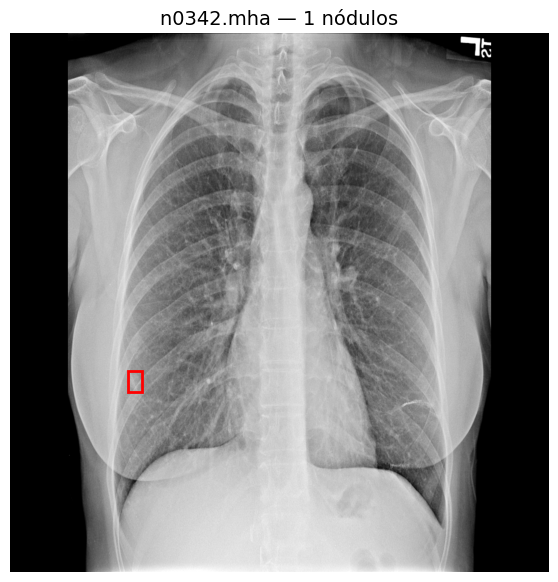

In [9]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import cv2
import numpy as np

def show_png_with_boxes(df, idx):
    # Obtener ruta y nombre del archivo
    path = df.loc[idx, "file_path"]
    img_name = df.loc[idx, "img_name"]
    print("Mostrando:", path)

    # Cargar imagen PNG
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        print("ERROR: No se pudo cargar la imagen")
        return

    # Normalización para visualización
    img = img.astype(np.float32)
    img = (img - img.min()) / (img.max() - img.min() + 1e-8)

    # Obtener todas las anotaciones de esta imagen
    rows = df[df["file_path"] == path]

    boxes = []
    for _, r in rows.iterrows():
        if r["label"] == 1:
            x1 = float(r["x"])
            y1 = float(r["y"])
            x2 = x1 + float(r["width"])
            y2 = y1 + float(r["height"])
            boxes.append((x1, y1, x2, y2))

    # ------------------------------
    #  VISUALIZACIÓN
    # ------------------------------
    fig, ax = plt.subplots(figsize=(7,7))
    ax.imshow(img, cmap='gray')
    ax.set_title(f"{img_name} — {len(boxes)} nódulos", fontsize=14)

    # Dibujar cada bounding box
    for (x1, y1, x2, y2) in boxes:
        rect = patches.Rectangle(
            (x1, y1), x2 - x1, y2 - y1,
            linewidth=2,
            edgecolor='red',
            facecolor='none'
        )
        ax.add_patch(rect)

    plt.axis("off")
    plt.show()
show_png_with_boxes(df, 1)

In [ ]:
import cv2
import numpy as np
import torch
dataset = Node21DetectionDatasetPNG(df)

img, target = dataset[1]

print(img.shape)
print(target)

torch.Size([3, 1024, 1024])
{'boxes': tensor([[223., 642., 250., 682.]]), 'labels': tensor([1]), 'area': tensor([1080.]), 'iscrowd': tensor([0]), 'image_id': tensor([1])}


### Preparació dels DataLoaders per a detecció

Aquesta cel·la defineix la funció `collate` necessària per a models de detecció, separa el dataset en entrenament i validació evitant *data leakage*, i crea els `Dataset` i `DataLoader` de PyTorch corresponents.


In [10]:
# 1. Collate
def detection_collate(batch):
    imgs = [item[0] for item in batch]
    targets = [item[1] for item in batch]
    return imgs, targets

# 2. Split
from sklearn.model_selection import train_test_split

images = df["file_path"].unique()

train_imgs, val_imgs = train_test_split(
    images, test_size=0.2, random_state=42
)

train_df = df[df["file_path"].isin(train_imgs)]
val_df   = df[df["file_path"].isin(val_imgs)]

# 3. Datasets
train_dataset = Node21DetectionDatasetPNG(train_df)
val_dataset   = Node21DetectionDatasetPNG(val_df)

# 4. Dataloaders
from torch.utils.data import DataLoader
train_loader = DataLoader(train_dataset, batch_size=2, shuffle=True,
                          collate_fn=detection_collate,
                          num_workers=2, pin_memory=True)

val_loader   = DataLoader(val_dataset, batch_size=2, shuffle=False,
                          collate_fn=detection_collate,
                          num_workers=2, pin_memory=True)

In [ ]:
for imgs, targets in train_loader:
    print("Batch size:", len(imgs))
    print("Image shape:", imgs[0].shape)
    print("Targets:", targets[0])
    break

Batch size: 2
Image shape: torch.Size([3, 1024, 1024])
Targets: {'boxes': tensor([], size=(0, 4)), 'labels': tensor([], dtype=torch.int64), 'area': tensor([]), 'iscrowd': tensor([], dtype=torch.int64), 'image_id': tensor([1113])}


### Definició de la Focal Loss

Aquesta cel·la implementa la funció de pèrdua *Focal Loss*, utilitzada per gestionar el desbalanceig de classes en problemes de detecció, penalitzant menys els exemples fàcils i focalitzant l’aprenentatge en els casos més difícils.


In [11]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
class FocalLoss(nn.Module):
    def __init__(self, alpha=0.25, gamma=2.0, reduction="mean"):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, logits, targets):
        ce_loss = F.cross_entropy(logits, targets, reduction="none")
        pt = torch.exp(-ce_loss)
        focal_loss = self.alpha * (1 - pt) ** self.gamma * ce_loss

        if self.reduction == "mean":
            return focal_loss.mean()
        elif self.reduction == "sum":
            return focal_loss.sum()
        else:
            return focal_loss


### Funció de pèrdua Fast R-CNN amb Focal Loss

Aquesta cel·la defineix una funció de pèrdua personalitzada per a models de detecció basats en Fast R-CNN.  
Utilitza *Focal Loss* per a la classificació i *Smooth L1 Loss* per a la regressió de bounding boxes, millorant el rendiment en escenaris amb fort desbalanceig de classes.


In [22]:
import torch.nn.functional as F

def fastrcnn_loss_focal(
    class_logits, box_regression, labels, regression_targets
):
    labels = torch.cat(labels, dim=0)
    regression_targets = torch.cat(regression_targets, dim=0)

    # --------------------
    # Clasificación (FOCAL)
    # --------------------
    classification_loss = focal_loss(class_logits, labels)

    # --------------------
    # Box regression 
    # --------------------
    sampled_pos_inds = torch.where(labels > 0)[0]
    labels_pos = labels[sampled_pos_inds]

    box_regression = box_regression.reshape(box_regression.size(0), -1, 4)

    box_loss = F.smooth_l1_loss(
        box_regression[sampled_pos_inds, labels_pos],
        regression_targets[sampled_pos_inds],
        beta=1 / 9,
        reduction="sum",
    )
    box_loss = box_loss / labels.numel()

    return classification_loss, box_loss


### Configuració del model Faster R-CNN amb pesos VinDr i Focal Loss

Aquesta cel·la construeix un model Faster R-CNN basat en ResNet-50, carrega pesos preentrenats en VinDr sense el capçal de classificació, congela parcialment el backbone i defineix un nou capçal adaptat al dataset NODE21.  
Finalment, s’integra la Focal Loss com a funció de pèrdua i es prepara el model per a l’entrenament.


In [ ]:
import torchvision
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
import torch

MODEL_DIR = "/content/drive/MyDrive/ML/DATASETS/NODE21/models"
MODEL_PATH = f"{MODEL_DIR}/fastercnn50_vindr.pth"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# -------------------------------------------------
# 1. Crear modelo base
# -------------------------------------------------
model = torchvision.models.detection.fasterrcnn_resnet50_fpn(
    weights=None,
    weights_backbone=None
)

# -------------------------------------------------
# 2. Cargar pesos VinDr (sin head)
# -------------------------------------------------
state_dict = torch.load(MODEL_PATH, map_location=device)

keys_to_remove = [
    "roi_heads.box_predictor.cls_score.weight",
    "roi_heads.box_predictor.cls_score.bias",
    "roi_heads.box_predictor.bbox_pred.weight",
    "roi_heads.box_predictor.bbox_pred.bias",
]

for k in keys_to_remove:
    if k in state_dict:
        del state_dict[k]

model.load_state_dict(state_dict, strict=False)

# -------------------------------------------------
# 3. Congelar backbone
# -------------------------------------------------
for p in model.backbone.body.parameters():
    p.requires_grad = False

for name, p in model.backbone.body.named_parameters():
    if name.startswith("layer4"):
        p.requires_grad = True

for name, p in model.backbone.named_parameters():
    if "fpn" in name:
        p.requires_grad = True

# -------------------------------------------------
# 4. Head NODE21 (2 clases)
# -------------------------------------------------
num_classes = 2
in_features = model.roi_heads.box_predictor.cls_score.in_features
model.roi_heads.box_predictor = FastRCNNPredictor(
    in_features,
    num_classes
)

# -------------------------------------------------
# 5. FOCAL LOSS 
# -------------------------------------------------
focal_loss = FocalLoss(alpha=0.25, gamma=2.0)

# PARCHEAR SOLO LA FUNCIÓN DE LOSS
model.roi_heads.fastrcnn_loss = fastrcnn_loss_focal

# -------------------------------------------------
# 6. Device + train
# -------------------------------------------------
model.to(device)
model.train()

print("Faster R-CNN VinDR + Focal Loss listo")




### Bucle d’entrenament d’una època

Aquesta cel·la implementa la funció d’entrenament d’una època del model de detecció.  
Processa els lots de dades, calcula i retropropaga les pèrdues, actualitza els pesos del model i registra les mètriques d’entrenament a Weights & Biases.


In [25]:
from tqdm import tqdm
import torch

def train_one_epoch(model, loader, optimizer, device):
    model.train()

    total_loss = 0.0
    cls_loss = 0.0
    box_loss = 0.0
    rpn_obj_loss = 0.0
    rpn_box_loss = 0.0

    loop = tqdm(loader, desc="Entrenando", leave=True)

    for images, targets in loop:
        images = [img.to(device) for img in images]
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        loss_dict = model(images, targets)
        loss = sum(loss_dict.values())

        if not torch.isfinite(loss):
            print("Loss no finita, batch omitido")
            continue

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Acumular pérdidas
        total_loss += loss.item()
        cls_loss += loss_dict["loss_classifier"].item()
        box_loss += loss_dict["loss_box_reg"].item()
        rpn_obj_loss += loss_dict["loss_objectness"].item()
        rpn_box_loss += loss_dict["loss_rpn_box_reg"].item()

        loop.set_postfix({
            "total": f"{loss.item():.3f}",
            "cls": f"{loss_dict['loss_classifier'].item():.3f}",
            "box": f"{loss_dict['loss_box_reg'].item():.3f}",
            "rpn": f"{loss_dict['loss_objectness'].item():.3f}"
        })

    n = len(loader)

    # LOG A WANDB (UNA SOLA VEZ POR EPOCH)
    wandb.log({
        "train/total_loss": total_loss / n,
        "train/classifier_loss": cls_loss / n,
        "train/box_loss": box_loss / n,
        "train/rpn_objectness": rpn_obj_loss / n,
        "train/rpn_box": rpn_box_loss / n,
    })

    return total_loss / n


In [26]:
from tqdm import tqdm
import torch

def evaluate_one_epoch(model, loader, device):
    # TorchVision detection necesita model.train() incluso en validación
    model.train()

    total_loss = 0.0
    cls_loss = 0.0
    box_loss = 0.0
    rpn_obj_loss = 0.0
    rpn_box_loss = 0.0

    loop = tqdm(loader, desc="Validando", leave=True)

    with torch.no_grad():
        for images, targets in loop:
            images = [img.to(device) for img in images]
            targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

            loss_dict = model(images, targets)
            loss = sum(loss_dict.values())

            # Protección NaNs / Infs
            if not torch.isfinite(loss):
                print("Loss no finita en validación, batch omitido")
                continue

            # Acumular pérdidas
            total_loss += loss.item()
            cls_loss += loss_dict["loss_classifier"].item()
            box_loss += loss_dict["loss_box_reg"].item()
            rpn_obj_loss += loss_dict["loss_objectness"].item()
            rpn_box_loss += loss_dict["loss_rpn_box_reg"].item()

            loop.set_postfix({
                "total": f"{loss.item():.3f}",
                "cls": f"{loss_dict['loss_classifier'].item():.3f}",
                "box": f"{loss_dict['loss_box_reg'].item():.3f}",
                "rpn": f"{loss_dict['loss_objectness'].item():.3f}"
            })

    n = len(loader)

    val_total = total_loss / n

    # LOG A WANDB (UNA VEZ POR EPOCH)
    wandb.log({
        "val/total_loss": val_total,
        "val/classifier_loss": cls_loss / n,
        "val/box_loss": box_loss / n,
        "val/rpn_objectness": rpn_obj_loss / n,
        "val/rpn_box": rpn_box_loss / n,
    })

    return val_total


### Avaluació del model en validació

Aquesta cel·la implementa la funció d’avaluació d’una època sobre el conjunt de validació.  
Calcula les pèrdues sense actualitzar els pesos del model i registra les mètriques de validació a Weights & Biases per al seguiment de l’entrenament.


In [27]:
class EarlyStopping:
    def __init__(self, patience=3, min_delta=0.0):
        self.patience = patience
        self.min_delta = min_delta
        self.best_loss = None
        self.counter = 0

    def step(self, val_loss):
        if self.best_loss is None:
            self.best_loss = val_loss
            return False

        if val_loss < self.best_loss - self.min_delta:
            self.best_loss = val_loss
            self.counter = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                return True

        return False


In [28]:
wandb.init(
    project="node21-fasterrcnn",
    name=f"vindr_focal_3ch_{RUN_ID}",
    config={
        "dataset": "NODE21",
        "pretrain": "VinDr-CXR",
        "architecture": "FasterRCNN-ResNet50-FPN",
        "channels": 3,
        "loss": "FocalLoss",
        "alpha": 0.25,
        "gamma": 2.0,
        "unfreeze": ["layer4", "fpn"],
        "optimizer": "AdamW",
        "lr": 1e-4,
        "batch_size": 2,
        "early_stopping": {
            "patience": 15,
            "min_delta": 1e-4
        }
    }
)

### Bucle principal d’entrenament i guardat de models

Aquesta cel·la configura l’optimitzador, executa el bucle d’entrenament durant múltiples èpoques i avalua el model en cada iteració.  
Inclou *early stopping*, guarda checkpoints per època, desa el millor model de l’execució i registra tota la informació rellevant a Weights & Biases.


In [29]:
import torch.optim as optim
import os
from datetime import datetime

MODEL_DIR = "/content/drive/MyDrive/ML/DATASETS/NODE21/models"


# Timestamp único por ejecución
#RUN_ID = datetime.now().strftime("%Y%m%d_%H%M%S")

print(f"Run ID: {RUN_ID}")


optimizer = optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-4,
    weight_decay=1e-4
)
wandb.log({
    "lr": optimizer.param_groups[0]["lr"]
})


num_epochs = 40
early_stopper = EarlyStopping(patience=15, min_delta=0.0001)

best_val_loss = float("inf")

for epoch in range(num_epochs):
    print(f"\n===== Epoch {epoch+1}/{num_epochs} =====")

    train_loss = train_one_epoch(model, train_loader, optimizer, device)
    val_loss   = evaluate_one_epoch(model, val_loader, device)

    print(f"Epoch {epoch+1}:")
    print(f"  → Train Loss: {train_loss:.4f}")
    print(f"  → Val Loss:   {val_loss:.4f}")

    wandb.log({"epoch": epoch + 1})

    # Guardar checkpoint por epoch
    checkpoint_path = (
        f"{MODEL_DIR}/checkpoint_epoch_{epoch+1:02d}_{RUN_ID}.pth"
    )
    torch.save(model.state_dict(), checkpoint_path)

    # Guardar mejor modelo de ESTA ejecución
    if val_loss < best_val_loss:
        best_val_loss = val_loss

        best_model_path = (
            f"{MODEL_DIR}/best_frcnn_node21_{RUN_ID}.pth"
        )
        torch.save(model.state_dict(), best_model_path)


        artifact = wandb.Artifact(
            name=f"best_frcnn_node21_{RUN_ID}",
            type="model",
            metadata={"epoch": epoch + 1, "val_loss": val_loss}
        )
        artifact.add_file(best_model_path)
        wandb.run.log_artifact(artifact)

        print("Guardado nuevo MEJOR MODELO de la ejecución")

    # Early stopping
    if early_stopper.step(val_loss):
        print(f"\n Early stopping activado en Epoch {epoch+1}")
        print(f"Mejor epoch = {epoch+1 - early_stopper.patience}")
        break

Run ID: 20251231_152453

===== Epoch 1/40 =====


Validando: 100%|██████████| 715/715 [11:16<00:00,  1.06it/s, total=0.254, cls=0.105, box=0.135, rpn=0.004]


Epoch 1:
  → Train Loss: 0.1005
  → Val Loss:   0.0906
Guardado nuevo MEJOR MODELO de la ejecución

===== Epoch 2/40 =====


Validando: 100%|██████████| 715/715 [02:02<00:00,  5.85it/s, total=0.279, cls=0.060, box=0.200, rpn=0.010]


Epoch 2:
  → Train Loss: 0.0849
  → Val Loss:   0.0923

===== Epoch 3/40 =====


...

Epoch 17:
  → Train Loss: 0.0329
  → Val Loss:   0.1576

===== Epoch 18/40 =====


Validando: 100%|██████████| 715/715 [02:04<00:00,  5.76it/s, total=0.059, cls=0.013, box=0.044, rpn=0.000]


Epoch 18:
  → Train Loss: 0.0311
  → Val Loss:   0.1866

===== Epoch 19/40 =====


Entrenando: 100%|█████████▉| 2857/2860 [15:16<00:00,  3.12it/s, total=0.000, cls=0.000, box=0.000, rpn=0.000]


KeyboardInterrupt: 

In [ ]:
wandb.finish()

In [ ]:
MODEL_DIR = "/content/drive/MyDrive/ML/DATASETS/NODE21/models"
MODEL_PATH = f"{MODEL_DIR}/node21_v2.3_3canales_frcnn_vindn_png_checkpoint_epoch_09_20251224_043211.pth"
MODEL_PATH = f"{MODEL_DIR}/node21_v2.3_3canales_frcnn_vindn_png_best_frcnn_node21_20251224_043211.pth"


### Càrrega del model Faster R-CNN entrenat

Aquesta cel·la reconstrueix l’arquitectura del model Faster R-CNN amb el mateix capçal utilitzat durant l’entrenament i carrega els pesos del checkpoint guardat.  
Finalment, es prepara el model en mode d’avaluació per a inferència o validació.


In [ ]:
import torchvision
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 1Crear modelo base
model = torchvision.models.detection.fasterrcnn_resnet50_fpn(
    weights=None,
    weights_backbone=None
)

# DEFINIR EL MISMO HEAD QUE SE USO EN EL ENTRENAMIENTO
num_classes = 2  # fondo + nódulo
in_features = model.roi_heads.box_predictor.cls_score.in_features
model.roi_heads.box_predictor = FastRCNNPredictor(
    in_features,
    num_classes
)

# Cargar el checkpoint entrenado
state_dict = torch.load(MODEL_PATH, map_location=device)
model.load_state_dict(state_dict)   # <-- ahora SÍ encaja

# Device + eval
model.to(device)
model.eval()

print("Modelo Faster R-CNN Node21 cargado correctamente.")


Modelo Faster R-CNN Node21 cargado correctamente.


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import torch

def show_prediction_2(model, dataset, idx, score_thresh=0.3, show_gt=True):
    model.eval()

    img, target = dataset[idx]

    # Imagen (mostramos un canal, RX en gris)
    img_np = img[0].cpu().numpy()
    image = img.to(device)

    with torch.no_grad():
        pred = model([image])[0]

    pred_boxes = pred["boxes"].cpu().numpy()
    pred_scores = pred["scores"].cpu().numpy()

    # Filtrar por score
    keep = pred_scores >= score_thresh
    pred_boxes = pred_boxes[keep]
    pred_scores = pred_scores[keep]

    fig, ax = plt.subplots(figsize=(7,7))
    ax.imshow(img_np, cmap='gray')

    # Ground Truth 
    if show_gt and len(target["boxes"]) > 0:
        for (x1, y1, x2, y2) in target["boxes"]:
            rect = patches.Rectangle(
                (x1, y1), x2-x1, y2-y1,
                linewidth=2, edgecolor='red', facecolor='none'
            )
            ax.add_patch(rect)

    # Predicciones
    for (x1, y1, x2, y2), s in zip(pred_boxes, pred_scores):
        rect = patches.Rectangle(
            (x1, y1), x2-x1, y2-y1,
            linewidth=2, edgecolor='lime', facecolor='none'
        )
        ax.add_patch(rect)
        ax.text(x1, y1, f"{s:.2f}", color="yellow", fontsize=10)

    plt.title(f"Predicciones Faster R-CNN (idx={idx})")
    plt.axis("off")
    plt.show()


### Visualització de prediccions del model

Aquesta cel·la defineix una funció per visualitzar les prediccions del model Faster R-CNN sobre una imatge del dataset.  
Mostra les bounding boxes reals (ground truth) i les deteccions del model, filtrades per un llindar de confiança, per facilitar l’anàlisi qualitativa dels resultats.


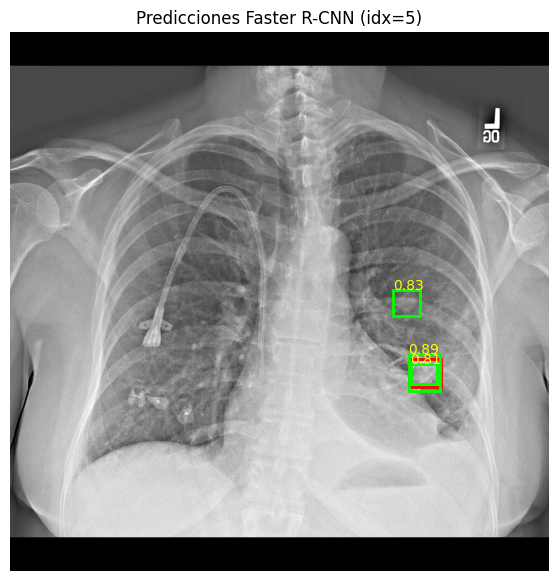

In [ ]:
show_prediction_2(model, train_dataset, 5,0.8)